# Loading the required libraries

In [17]:
library(showtext)
library(tidyverse)
library(ggplot2)
library(readr)
library(stringr)
library(Statial)
library(rstatix)
library(ComplexHeatmap)
library(circlize)
library(jsonlite)
library(reticulate)
library(data.table)
library(scales)
library(data.table)
library(cowplot)
library(survival)
library(survminer)
library(patchwork)
library(compositions)
library(ggbeeswarm)
library(purrr)
library(broom)
library(scales)
library(ggh4x)
font_add("Arial", "/System/Library/Fonts/Supplemental/Arial.ttf")
showtext_auto()

Loading required package: ggpubr


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend



Attaching package: ‘survminer’


The following object is masked from ‘package:survival’:

    myeloma




## Figures and Files Setup

### Results main directory

In [6]:
data_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results"
results_dir = "/Users/jawadalaaedeen/Desktop/PhD/NMC/results/figure_2"

### Color palettes

In [14]:
myeloid_palette <- c(
  "MDSCs" = "#332288",
  "M2 macrophages" = "#66A61E",
  "M1 macrophages" = "#00557F",
  "M1/M2 macrophages" = "#BBCCEE",
  "DCs" = "#E69F00",
  "Granulocytes" = "#B85AA6",
  "Mast cells" = "#8E006A"
)

lymphoid_palette <- c(
  "CD8+ T cells" = "#B2182B",
  "CD4+ T cells" = "#EF8A62",
  "Treg T cells" = "#FFCCCC",
  "NK cells" = "#0096FF",
  "B cells" = "#E6C84F",
  "PCs" = "#F4E58A"
)

non_immune_palette <- c(
  "Actin+ cells" = "#B39DDB",
  "Endothelial cells" = "#7F8F6A",
  "Lymphatic endothelial cells" = "#A6B08A",
  "Epithelial cells" = "#E3B07A"
)


other_palette <- c(
  "Tumor cells" = "#44AA99",
  "NFC" = "#DDDDDD"
)

full_palette <- c(
  myeloid_palette,
  lymphoid_palette,
  non_immune_palette,
  other_palette
)

tumor_site_colors <- c(
"Lung" = "#F0F0F0",     # very light
"Head and Neck" = "#B0B0B0",  # medium
"Extrahepatic" = "#505050" # darker
)


main_group_colors <- c(
  "Myeloid"  = "#332288",
  "Lymphoid" = "#B2182B",
  "Non-immune" = "#B39DDB",
  "Tumor" = "#44AA99",
  "NFC" = "#DDDDDD"
)

color_for_ratios <- c(
  "Granulocytes-T cells ratio"    = "#B85AA6",
  "Macrophages-T cells ratio" = "#66A61E",
  "MDSCs-T cells ratio" = "#332288"
)

## Object for analysis

In [7]:
celltype_metadata <- read_csv(
  paste0(data_dir, "/celltype_metadata_final.csv")
) %>%
  mutate(is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic")) %>%
  mutate(patient_num = as.numeric(str_extract(patient_exp, "(?<=NUT_)\\d+")),
         roi_num = as.numeric(str_extract(patient_exp, "(?<=ROI)\\d+"))) %>%
  arrange(patient_num, roi_num) %>%
  select(-patient_num, -roi_num)
celltype_metadata$patient_exp <- factor(celltype_metadata$patient_exp, levels = unique(celltype_metadata$patient_exp))
celltype_metadata$patient_ID <- factor(celltype_metadata$patient_ID, levels = unique(celltype_metadata$patient_ID))
patient_ID_order <- unique(celltype_metadata$patient_ID)
patient_exp_order <- unique(celltype_metadata$patient_exp)


myeloid <-  c("M1 macrophages", "M2 macrophages", "M1/M2 macrophages", "DCs", "Granulocytes", "MDSCs", "Mast cells")
lymphoid <- c("CD4+ T cells", "CD8+ T cells", "Treg T cells", "NK cells", "B cells", "PCs")
nonimmune <- c("Actin+ cells", "Endothelial cells", "Lymphatic endothelial cells", "Epithelial cells")

celltype_metadata <- celltype_metadata %>%
  mutate(
    cell_category_simplified = case_when(
      cell_category %in% myeloid ~ "Myeloid",
      cell_category %in% lymphoid ~ "Lymphoid",
      cell_category %in% nonimmune ~ "Non-immune",
      cell_category == "NFC" ~ "NFC",
      cell_category == "Tumor cells" ~ "Tumor"
    ),
    cell_category_simplified = factor(
      cell_category_simplified,
      levels = c("NFC", "Non-immune", "Lymphoid", "Myeloid", "Tumor")
    )
  ) 

Rows: 553331 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): cell_type, cell_category, patient_ID, exp_name, patient_exp, sample...
dbl (6): cell_id, Cell Center X, Cell Center Y, run, rois, survival_time_months
lgl (1): is_sample_primary

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [20]:
survival_df <- celltype_metadata %>%
    select(patient_ID, tumor_site, survival_time_months) %>%
    distinct() %>%
    mutate(event = ifelse(patient_ID == "NUT_1", 0, 1),
        tumor_site = factor(tumor_site, levels = c("Lung", "Head and Neck", "Extrahepatic")), 
    patient_ID = factor(patient_ID, levels = patient_ID_order),
    is_lung = ifelse(tumor_site == "Lung", "Lung", "Head and Neck/Extrahepatic"),
        event = as.numeric(event),
        survival_time_months = as.numeric(survival_time_months)
      )

survival_df_order <- survival_df %>%
arrange(tumor_site, survival_time_months) %>%
mutate(patient_ID = factor(patient_ID, levels = unique(patient_ID)))

patient_ID_survival_order <-survival_df_order %>%
pull(patient_ID)

## A

In [8]:
#Make a barplot of number of patients per tumor site 
tumor_site_df <- celltype_metadata %>%
    distinct(patient_ID, tumor_site) %>%
    group_by(tumor_site) %>%
    summarise(Patients = n())

#Make a barplot of number of patients per tumor site 
tumor_site_df_rois <- celltype_metadata %>%
    distinct(patient_ID, patient_exp, tumor_site) %>%
    group_by(tumor_site) %>%
    summarise(ROIs = n())

tumor_site_df <- tumor_site_df %>%
left_join(tumor_site_df_rois, by = "tumor_site") %>%
pivot_longer(cols = c(Patients, ROIs), names_to = "patient/roi", values_to = "count")
tumor_site_df

tumor_site,patient/roi,count
<chr>,<chr>,<int>
Extrahepatic,Patients,1
Extrahepatic,ROIs,2
Head and Neck,Patients,4
Head and Neck,ROIs,7
Lung,Patients,8
Lung,ROIs,12


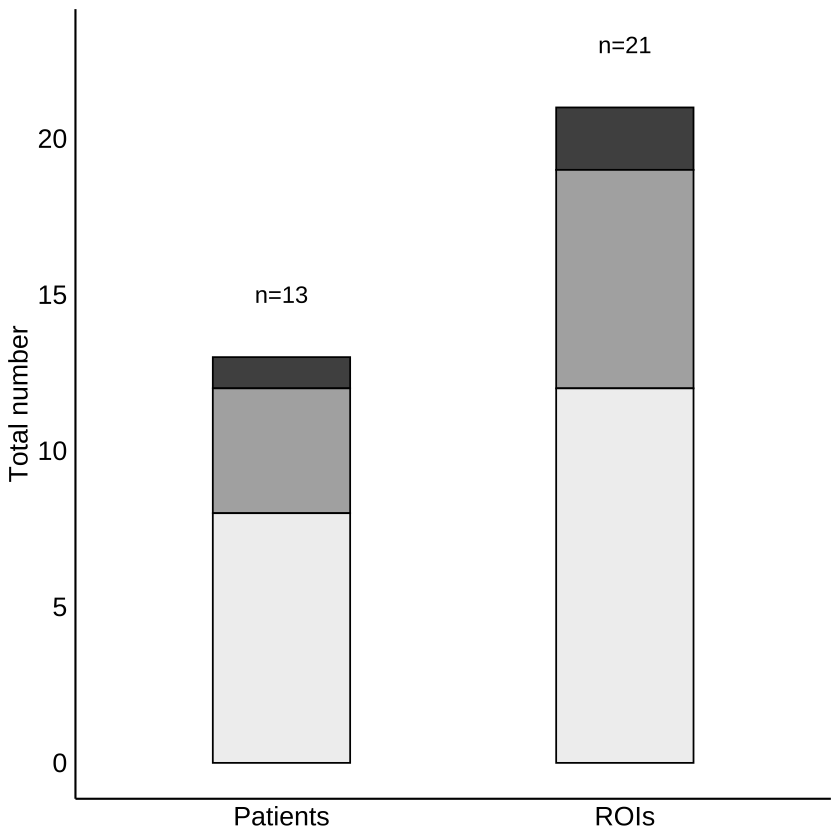

In [11]:
p_sites <- ggplot(tumor_site_df, aes(x = `patient/roi`, y = count, fill = tumor_site)) +
  geom_bar(stat = "identity", width = 0.4, colour = "black") +
  theme_minimal() +
  labs(y = "Total number") +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 16, colour = "black"),
    legend.text  = element_text(size = 16),
    legend.title = element_text(size = 16),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "none",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  axis.title.x.bottom = element_blank(),
  panel.grid = element_blank()
  ) +
  scale_fill_manual(values = tumor_site_colors) +
    annotate(
    "text",
    x = 1,
    y =  15,
    label = paste0("n=13"),
    size = 5,
    color = "black"
  )  +
  annotate(
    "text",
    x = 2,
    y =  23,
    label = paste0("n=21"),
    size = 5,
    color = "black"
  ) 
# p_sites
ggsave(
  filename = paste0(results_dir, "/samples_rois_tumor_site.pdf"),
  plot = p_sites,
  width = 4,
  height = 4,
  dpi = 300
)
p_sites

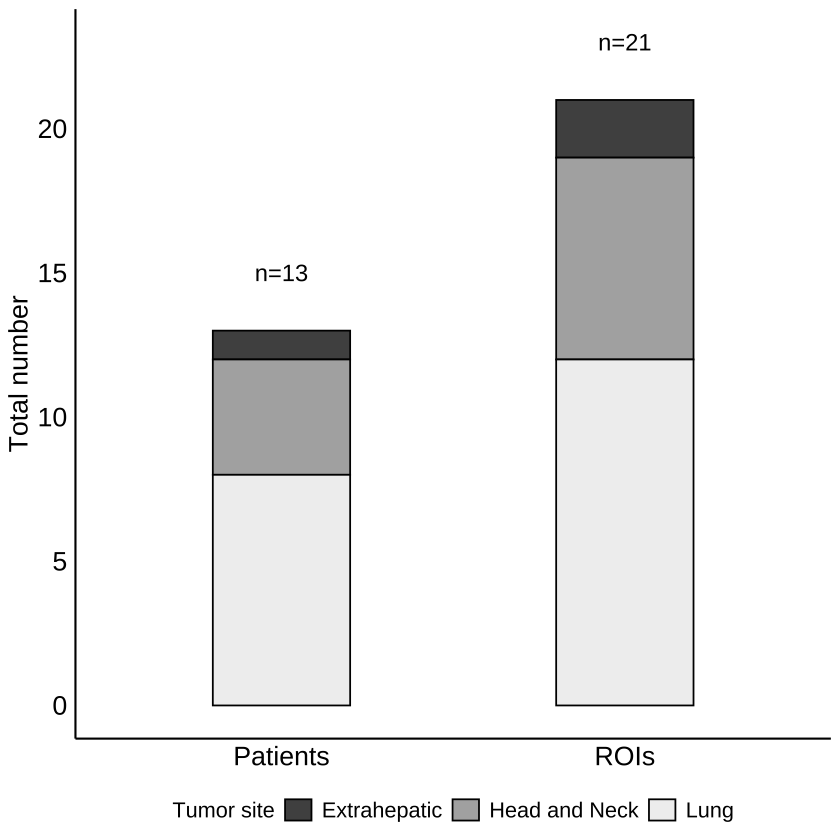

In [13]:
p_sites_legend <- ggplot(tumor_site_df, aes(x = `patient/roi`, y = count, fill = tumor_site)) +
  geom_bar(stat = "identity", width = 0.4, colour = "black") +
  theme_minimal() +
  labs(y = "Total number") +
  theme(
    axis.text.y = element_text(size = 16, colour = "black"),
    axis.text.x = element_text(size = 16, colour = "black"),
    axis.title  = element_text(size = 16, colour = "black"),
    legend.text  = element_text(size = 13),
    legend.title = element_text(size = 13),
    legend.key.height = unit(0.5, "cm"),
    legend.position = "bottom",
    panel.border = element_blank(),
  axis.line.x.bottom = element_line(colour="black", linewidth=0.6),
  axis.line.x.top    = element_line(colour="black", linewidth=0.6),
  axis.line.y.left   = element_line(colour="black", linewidth=0.6),
  axis.line.y.right  = element_blank(),
  axis.text.x.top  = element_blank(),
  axis.ticks.x.top = element_blank(),
  axis.title.x.top = element_blank(),
  axis.title.x.bottom = element_blank(),
  panel.grid = element_blank()
  ) +
  scale_fill_manual(values = tumor_site_colors) +
    annotate(
    "text",
    x = 1,
    y =  15,
    label = paste0("n=13"),
    size = 5,
    color = "black"
  )  +
  annotate(
    "text",
    x = 2,
    y =  23,
    label = paste0("n=21"),
    size = 5,
    color = "black"
  )  +
  guides(fill=guide_legend(title="Tumor site"))

#pick up the legend only
legend_sites <- get_legend(p_sites_legend)
ggsave(
  filename = paste0(results_dir, "/samples_rois_tumor_site_legend.pdf"),
  plot = legend_sites,
  width = 5,
  height = 1,
  dpi = 300
)
p_sites_legend

## B

In [23]:
# Fit survival
fit <- survfit(Surv(survival_time_months, event) ~ is_lung, data = survival_df)
  
  # Plot
 survival_tumor_site_plot <-  ggsurvplot(
    fit,
    data = survival_df,
    pval = TRUE,
    conf.int = TRUE,
    risk.table = TRUE,
    risk.table.height = 0.25,
    pval.coord = c(17, 0.7),
    xlim = c(0, 20),
    break.time.by = 5,
    palette = c("#2E86AB", "#E74C3C"),
    xlab = "Time (months)",
    ylab = "Survival probability",
    title = "Survival by tumor origin site",
    legend.title = "Origin site",
    legend.labs = c("None-Lung", "Lung"),
    risk.table.y.text.col = TRUE,
    risk.table.y.text = FALSE,
    ggtheme = theme_classic(base_size = 13, base_family = "Arial")
  )

  ggsave(
  filename = paste0(results_dir, "/survival_plot_by_tumor_site.pdf"), 
  plot = survival_tumor_site_plot$plot, 
  width = 7, 
  height = 6, 
  dpi = 300)

  ggsave(
  filename = paste0(results_dir, "/survival_plot_by_tumor_site_table.pdf"), 
  plot = survival_tumor_site_plot$table, 
  width = 7, 
  height = 2, 
  dpi = 300)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the ggpubr package.
  Please report the issue at <https://github.com/kassambara/ggpubr/issues>.”
Ignoring unknown labels:
• colour : "Origin site"


## D

In [24]:
plot_highlight <- function(df, highlight_levels, title = NULL,
                           bg_color = "#D9D9D9", bg_alpha = 1,
                           pt_size_bg = 1.5, pt_size_fg = 1.5) {

  df_bg <- df %>% dplyr::filter(!cell_category %in% highlight_levels)
  df_fg <- df %>% dplyr::filter(cell_category %in% highlight_levels)

  # palette restricted to highlighted cells (keeps your exact colors)
  pal_hl <- full_palette[highlight_levels]
  pal_hl <- pal_hl[!is.na(pal_hl)]  # safety if some names not present

  ggplot() +
    geom_point(
      data = df_bg,
      aes(x = `Cell Center X`, y = `Cell Center Y`),
      color = bg_color,
      alpha = bg_alpha,
      size = pt_size_bg
    ) +
    geom_point(
      data = df_fg,
      aes(x = `Cell Center X`, y = `Cell Center Y`, color = cell_category),
      alpha = 0.95,
      size = pt_size_fg
    ) +
    scale_color_manual(
      values = pal_hl,
      breaks = highlight_levels,   # <- legend entries limited to highlighted
      drop = TRUE
    ) +
    coord_equal() +
    theme_void() +
    theme(
      legend.title = element_blank(),
      plot.title = element_text(hjust = 0.5),
      legend.position = "none"
    ) +
    ggtitle(title) +
    scale_y_reverse()
}  


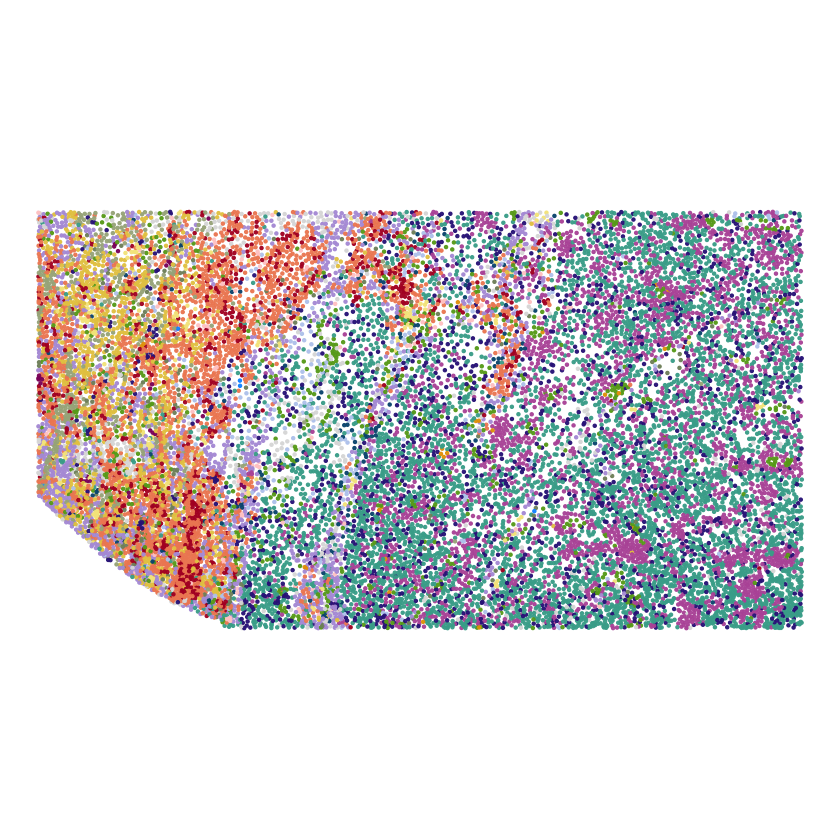

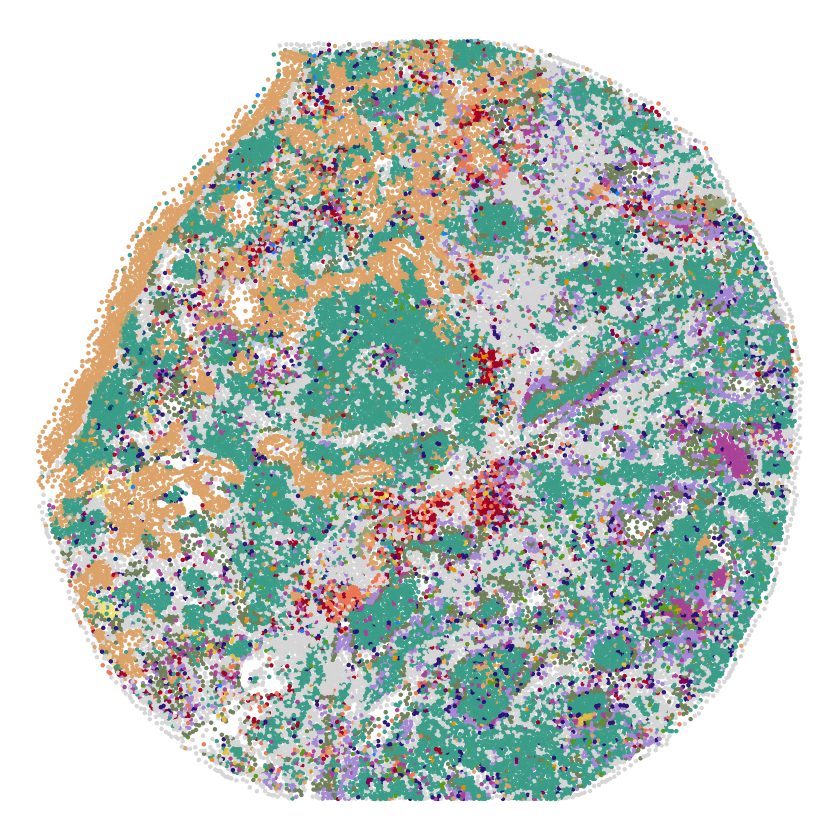

In [25]:
all_cells = celltype_metadata %>%
  pull(cell_category) %>%
    unique()

exp <- "NUT_9_ROI3"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 0.6, pt_size_fg = 0.6,
  highlight_levels = all_cells)
p

ggsave(filename = paste0(results_dir, "/NUT_9_ROI3_entire.svg"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")


ggsave(filename = paste0(results_dir, "/NUT_9_ROI3_entire.png"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")

exp <- "NUT_5_ROI10"
df <- celltype_metadata %>%
  filter(patient_exp == exp)

p <- plot_highlight(
  df,
  pt_size_bg = 0.6, pt_size_fg = 0.6,
  highlight_levels = all_cells)
p

ggsave(filename = paste0(results_dir, "/NUT_5_ROI10_entire.svg"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")


ggsave(filename = paste0(results_dir, "/NUT_5_ROI10_entire.png"),
       plot = p,
       width = 10,
       height = 10,
       dpi = 300,
       bg = "white")